In [4]:
!git clone https://github.com/Marco-Velazz/scratchpad
%run ./scratchpad/get_data.py

fatal: destination path 'scratchpad' already exists and is not an empty directory.


# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

**Q1 Answers**
1. A model is linear when it is linear in its parameters. This means the coefficients are not multiplied together or inside nonlinear functions. The predictors can be transformed, but the coefficients must enter the model linearly.

2. The coefficient represents the difference in the predicted value of the outcome compared to the reference category, while keeping other variables constant. The intercept represents the baseline group.

3. It can technically be used, but it is not ideal because linear regression predicts continuous values that can be below 0 or above 1. Classification usually needs probabilities between 0 and 1, which is why models like logistic regression are preferred.

4. Signs include very good performance on the training data but poor performance on test data, very large coefficients, and the model being sensitive to small changes in the data.

5. Multicollinearity happens when two or more predictors are highly correlated, making it hard to estimate their separate effects. In two-stage least squares, one variable is first predicted using other variables, and then that predicted value is used in the regression to reduce the correlation problem.

6. You can add polynomial terms, interaction terms, or transform variables
using functions like log or square root.

7. The slope coefficient shows how much the predicted value of *y* changes when *x* increases by one unit, while holding other variables constant.

8. A train/test split divides the data once into training and testing sets.
k-fold cross validation splits the data into k groups and repeatedly trains and tests the model, which gives a more reliable estimate of model performance.

9. The value of *k* is usually chosen based on common practice. 5-fold or 10-fold cross validation are the most common choices because they balance accuracy and computation time.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [5]:
import pandas as pd
df = pd.read_csv("/content/data/Q1_clean.csv")
df.columns

Index(['Price', 'Review Scores Rating', 'Neighbourhood ', 'Property Type',
       'Room Type'],
      dtype='object')

In [6]:
df = df.rename(columns={"Review Scores Rating": "Review_Scores_Rating",
                        "Neighbourhood ": "Neighbourhood"})
df[["Price", "Review_Scores_Rating", "Neighbourhood"]].head()

,Price,Review_Scores_Rating,Neighbourhood
0,549,96.0,Manhattan
1,149,100.0,Brooklyn
2,250,100.0,Manhattan
3,90,94.0,Brooklyn
4,270,90.0,Manhattan


In [7]:
df.groupby("Neighbourhood")[["Price","Review_Scores_Rating"]].mean()

,Price,Review_Scores_Rating
Neighbourhood,,
Bronx,75.276498,91.654378
Brooklyn,127.747378,92.363497
Manhattan,183.664286,91.801496
Queens,96.857233,91.549057
Staten Island,146.166667,90.843750


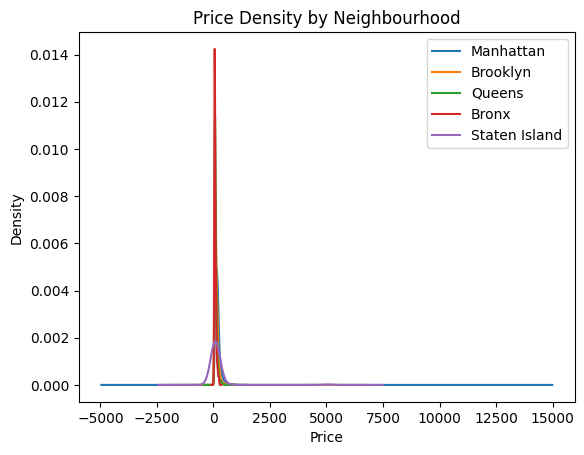

In [8]:
import matplotlib.pyplot as plt

for n in df["Neighbourhood"].unique():
    df[df["Neighbourhood"] == n]["Price"].plot(kind="density", label=n)

plt.title("Price Density by Neighbourhood")
plt.xlabel("Price")
plt.legend()
plt.show()

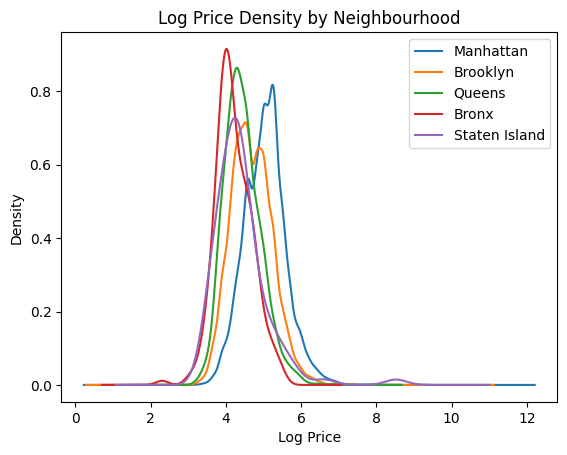

In [9]:
import numpy as np

df["log_price"] = np.log(df["Price"])

for n in df["Neighbourhood"].unique():
    df[df["Neighbourhood"] == n]["log_price"].plot(kind="density", label=n)

plt.title("Log Price Density by Neighbourhood")
plt.xlabel("Log Price")
plt.legend()
plt.show()

In [10]:
import statsmodels.formula.api as smf

model1 = smf.ols("Price ~ C(Neighbourhood)", data=df).fit()
model1.params

,0
Intercept,75.276498
C(Neighbourhood)[T.Brooklyn],52.470881
C(Neighbourhood)[T.Manhattan],108.387789
C(Neighbourhood)[T.Queens],21.580735
C(Neighbourhood)[T.Staten Island],70.890169


In [11]:
model2 = smf.ols("Price ~ Review_Scores_Rating", data=df).fit()
model2.params

,0
Intercept,60.878391
Review_Scores_Rating,1.020827


In [12]:
model3 = smf.ols("Price ~ C(Neighbourhood) + Review_Scores_Rating", data=df).fit()
model3.params

,0
Intercept,-23.812561
C(Neighbourhood)[T.Brooklyn],51.704240
C(Neighbourhood)[T.Manhattan],108.228737
C(Neighbourhood)[T.Queens],21.694600
C(Neighbourhood)[T.Staten Island],71.766552
Review_Scores_Rating,1.081116


In [13]:
model4 = smf.ols("Price ~ C(Neighbourhood) * Review_Scores_Rating", data=df).fit()
model4.params

,0
Intercept,22.638385
C(Neighbourhood)[T.Brooklyn],-16.392990
C(Neighbourhood)[T.Manhattan],41.315429
C(Neighbourhood)[T.Queens],28.259701
C(Neighbourhood)[T.Staten Island],2963.071040
Review_Scores_Rating,0.574311
C(Neighbourhood)[T.Brooklyn]:Review_Scores_Rating,0.741165
C(Neighbourhood)[T.Manhattan]:Review_Scores_Rating,0.729703
C(Neighbourhood)[T.Queens]:Review_Scores_Rating,-0.072294
C(Neighbourhood)[T.Staten Island]:Review_Scores_Rating,-31.831748


In [14]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

y = df["Price"]

# Model 4: neighbourhood only
X1 = df[["Neighbourhood"]]

pipe1 = Pipeline([
    ("encode", OneHotEncoder(drop="first")),
    ("model", LinearRegression())
])

cv1 = -cross_val_score(pipe1, X1, y, cv=5, scoring="neg_root_mean_squared_error").mean()


# Model 5: rating only
X2 = df[["Review_Scores_Rating"]]

cv2 = -cross_val_score(LinearRegression(), X2, y, cv=5,
                       scoring="neg_root_mean_squared_error").mean()


# Model 6: neighbourhood + rating
X3 = df[["Neighbourhood","Review_Scores_Rating"]]

pipe3 = Pipeline([
    ("encode", ColumnTransformer([
        ("cat", OneHotEncoder(drop="first"), ["Neighbourhood"])
    ], remainder="passthrough")),
    ("model", LinearRegression())
])

cv3 = -cross_val_score(pipe3, X3, y, cv=5,
                       scoring="neg_root_mean_squared_error").mean()

cv1, cv2, cv3

(np.float64(143.13955283691485),
 np.float64(146.32059499618637),
 np.float64(142.82648122047743))

**Q2 Answers**
1. The average price per night and review score were computed using groupby. The borough with the highest average price is Manhattan, with an average price of about 183.66 per night. The Bronx has the lowest average price at about 75.28 per night.

2. The kernel density plots show that the original price distribution is strongly right-skewed, meaning there are many lower prices and a few very high prices. After applying log(price), the distributions become more symmetric and easier to compare across boroughs. Manhattan's distribution is shifted furthest to the right, indicating it generally has the highest prices.

3. Brooklyn: about 52.47 higher, Manhattan: about 108.39 higher, Queens: about 21.58 higher, Staten Island: about 70.89 higher. The intercept represents the Bronx mean, and each coefficient shows how much higher the average price is relative to the Bronx.

4. The slope coefficient is about 1.02. This means that for each 1-point increase in review score rating, the predicted price per night increases by about 1.02 on average.

5. When both neighbourhood and review score are included, the slope on review score increases slightly to about 1.08. The neighbourhood coefficients remain very similar, meaning borough differences in price do not change much after controlling for review scores.

6. The slopes for Bronx, Brooklyn, Manhattan, and Queens are fairly similar (roughly between 0.5 and 1.3). Staten Island has a very different slope, likely due to a small number of observations.

7. Cross-validation results: Neighbourhood model RMSE ≈ 143.14, Review score model RMSE ≈ 146.32, Neighbourhood + Review score model RMSE ≈ 142.83. The model including both neighbourhood and review score performs best because it has the lowest prediction error.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [15]:
import pandas as pd

df = pd.read_csv("/content/data/cars_hw.csv")
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [16]:
df.columns

Index(['Unnamed: 0', 'Make', 'Make_Year', 'Color', 'Body_Type', 'Mileage_Run',
       'No_of_Owners', 'Seating_Capacity', 'Fuel_Type', 'Transmission',
       'Transmission_Type', 'Price'],
      dtype='object')

In [17]:
df["Price"].describe()

,Price
count,9.760000e+02
mean,7.410195e+05
std,3.673234e+05
min,1.880000e+05
25%,4.757500e+05
50%,6.665000e+05
75%,8.830000e+05
max,2.941000e+06


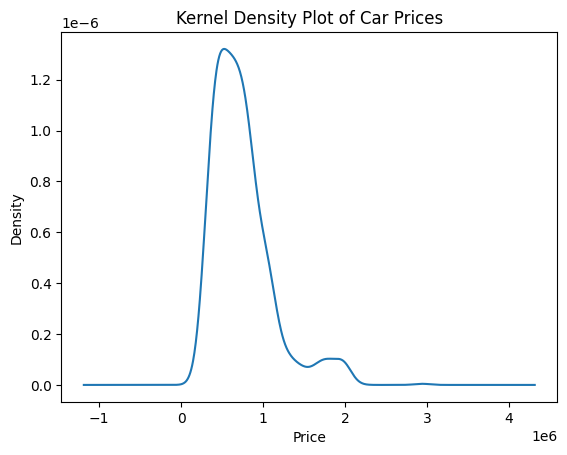

In [18]:
import matplotlib.pyplot as plt

df["Price"].plot(kind="density")
plt.title("Kernel Density Plot of Car Prices")
plt.xlabel("Price")
plt.show()

In [19]:
df.groupby("Body_Type")["Price"].describe()

,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.050952e+05,72849.780207,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.339773e+05,173086.729837,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.264211e+05,184093.488526,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.097841e+05,286736.770092,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.176495e+06,417479.028217,559000.0,860000.0,1065000.0,1491250.0,2100000.0


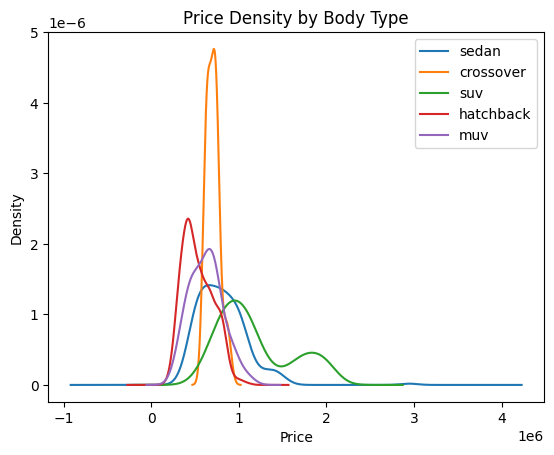

In [20]:
for b in df["Body_Type"].unique():
    df[df["Body_Type"] == b]["Price"].plot(kind="density", label=b)

plt.title("Price Density by Body Type")
plt.xlabel("Price")
plt.legend()
plt.show()

In [21]:
import statsmodels.formula.api as smf

model1 = smf.ols("Price ~ Seating_Capacity", data=df).fit()
model1.params

,0
Intercept,439032.014102
Seating_Capacity,59267.998037


In [22]:
model2 = smf.ols("Price ~ C(Seating_Capacity)", data=df).fit()
model2.params

,0
Intercept,1.880000e+05
C(Seating_Capacity)[T.5],5.464839e+05
C(Seating_Capacity)[T.6],1.456000e+06
C(Seating_Capacity)[T.7],7.359487e+05
C(Seating_Capacity)[T.8],2.718000e+05


In [23]:
df["Age"] = 2026 - df["Make_Year"]
df[["Make_Year","Age"]].head()

,Make_Year,Age
0,2017,9
1,2016,10
2,2019,7
3,2017,9
4,2017,9


In [24]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

X = df[["Age"]]
y = df["Price"]

kf = KFold(n_splits=10, shuffle=True, random_state=1)

degrees = range(1,11)
rmse = []

for d in degrees:

    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("model", LinearRegression())
    ])

    scores = cross_val_score(pipe, X, y, cv=kf,
                             scoring="neg_root_mean_squared_error")

    rmse.append(-scores.mean())

cv_table = pd.DataFrame({
    "degree": degrees,
    "rmse": rmse
})

cv_table

,degree,rmse
0,1,310378.396887
1,2,310457.787568
2,3,309616.738130
3,4,308930.145216
4,5,307509.787490
5,6,307682.560374
6,7,306600.446232
7,8,307099.696956
8,9,307103.474281
9,10,306723.547736


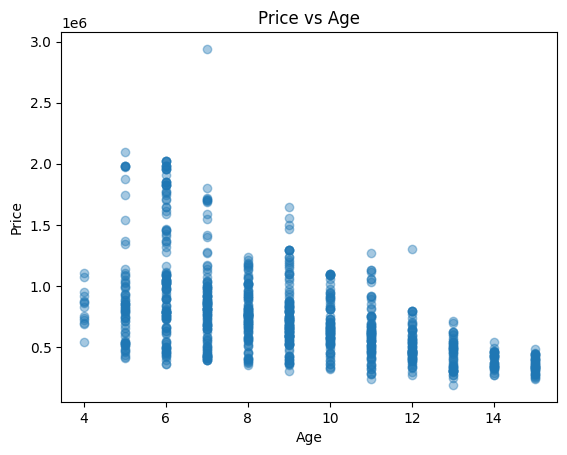

In [25]:
import matplotlib.pyplot as plt

plt.scatter(df["Age"], df["Price"], alpha=0.4)
plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price vs Age")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


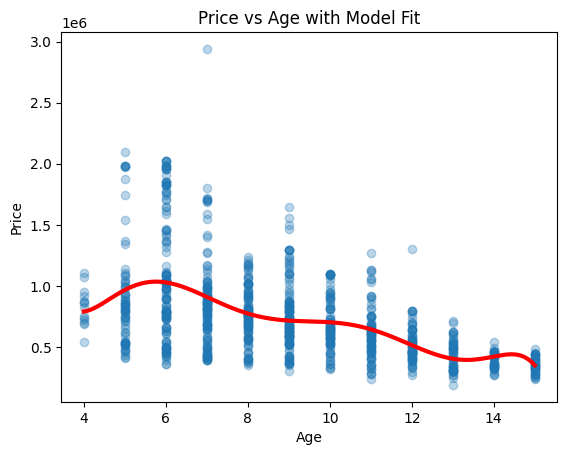

In [26]:
best_degree = 7

pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
    ("model", LinearRegression())
])

pipe.fit(X, y)

age_grid = np.linspace(df["Age"].min(), df["Age"].max(), 200).reshape(-1,1)
pred = pipe.predict(age_grid)

plt.scatter(df["Age"], df["Price"], alpha=0.3)
plt.plot(age_grid, pred, color="red", linewidth=3)
plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price vs Age with Model Fit")
plt.show()

**Q3 Answers**
1. The Price variable has a mean of about 741,020 rupees, with a minimum of 188,000 and a maximum of 2,941,000. The kernel density plot shows that most car prices are concentrated between about 400,000 and 1,000,000 rupees, with a long right tail for more expensive vehicles.

2. Using groupby and describe, SUVs are the most expensive car type on average with a mean price of about 1,176,495 rupees. Sedans are the second most expensive with an average of about 809,784 rupees. SUVs also have the largest standard deviation (about 417,479), meaning they have the most variance in price.

3. The slope coefficient for Seating_Capacity is about 59,268. This means that for each additional seat, the predicted car price increases by about 59,268 rupees on average.

4. When Seating_Capacity is treated as a categorical variable, the differences in price across seat counts are not perfectly linear. Some seat categories, such as 6 seats, have much higher prices than expected from a simple linear relationship.

5. A new variable Age was created using Age = 2026 − Make_Year. Using 10-fold cross validation to test polynomial models of Age, the lowest RMSE occurs at degree 7, so the optimal number of powers of Age to include in the regression is 7.

6. The scatter plot of Price against Age shows that car prices generally decrease as vehicles get older. The polynomial regression curve captures this downward trend reasonably well, although there is still noticeable variability in prices at each age level.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [27]:
heart = pd.read_csv("/content/data/heart_hw.csv")

print(heart.head())
print()
print(heart.info())
print()
print(heart["transplant"].value_counts(dropna=False))
print()
print(heart["y"].value_counts(dropna=False))

   Unnamed: 0  age transplant  y
0           1   53    control  0
1           2   43    control  0
2           3   52    control  0
3           4   52    control  0
4           5   54    control  0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  103 non-null    int64 
 1   age         103 non-null    int64 
 2   transplant  103 non-null    object
 3   y           103 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 3.3+ KB
None

transplant
treatment    69
control      34
Name: count, dtype: int64

y
0    75
1    28
Name: count, dtype: int64


In [28]:
# Proportion surviving in each group
group_survival = heart.groupby("transplant")["y"].mean()
print(group_survival)

# Extract values
a = group_survival["control"]
b = group_survival["treatment"]

# Average Treatment Effect
ATE = b - a

print("\nControl survival proportion (a):", a)
print("Treatment survival proportion (b):", b)
print("Average Treatment Effect (ATE = b - a):", ATE)

transplant
control      0.117647
treatment    0.347826
Name: y, dtype: float64

Control survival proportion (a): 0.11764705882352941
Treatment survival proportion (b): 0.34782608695652173
Average Treatment Effect (ATE = b - a): 0.23017902813299232


In [29]:
# Linear regression of survival on transplant
model1 = smf.ols("y ~ transplant", data=heart).fit()

print(model1.summary())

# Extract coefficients for easier comparison
intercept = model1.params["Intercept"]
transplant_coef = model1.params["transplant[T.treatment]"]

print("\nIntercept:", intercept)
print("Transplant coefficient:", transplant_coef)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Tue, 17 Mar 2026   Prob (F-statistic):             0.0133
Time:                        19:41:07   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [30]:
# Regression controlling for age
model2 = smf.ols("y ~ transplant + age", data=heart).fit()

print(model2.summary())

# Extract coefficients
intercept2 = model2.params["Intercept"]
transplant_coef2 = model2.params["transplant[T.treatment]"]
age_coef2 = model2.params["age"]

print("\nIntercept:", intercept2)
print("Transplant coefficient:", transplant_coef2)
print("Age coefficient:", age_coef2)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           0.000357
Time:                        19:41:32   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

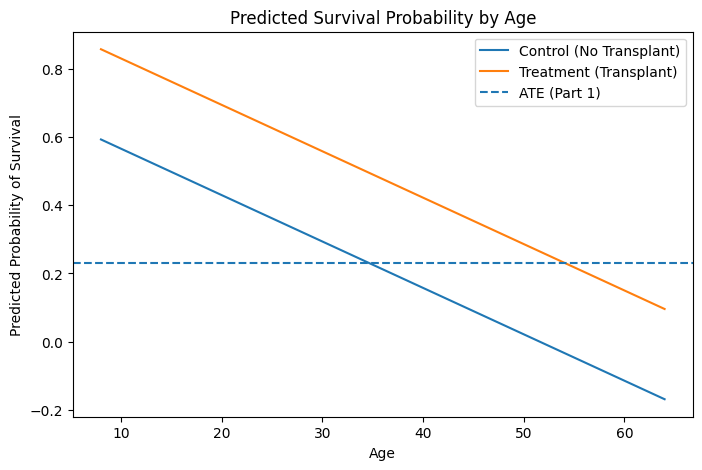

In [31]:
# Create an age range for predictions
age_range = np.linspace(heart["age"].min(), heart["age"].max(), 100)

# Create prediction datasets
control_df = pd.DataFrame({
    "age": age_range,
    "transplant": "control"
})

treatment_df = pd.DataFrame({
    "age": age_range,
    "transplant": "treatment"
})

# Predict survival probabilities
control_pred = model2.predict(control_df)
treatment_pred = model2.predict(treatment_df)

# Plot predictions
plt.figure(figsize=(8,5))

plt.plot(age_range, control_pred, label="Control (No Transplant)")
plt.plot(age_range, treatment_pred, label="Treatment (Transplant)")

# Add dashed horizontal line for ATE
plt.axhline(ATE, linestyle="--", label="ATE (Part 1)")

plt.xlabel("Age")
plt.ylabel("Predicted Probability of Survival")
plt.title("Predicted Survival Probability by Age")
plt.legend()

plt.show()

In [32]:
# Interaction model
model3 = smf.ols("y ~ transplant * age", data=heart).fit()

print(model3.summary())

# Extract coefficients
print("\nCoefficients:")
print(model3.params)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           0.000310
Time:                        19:50:52   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

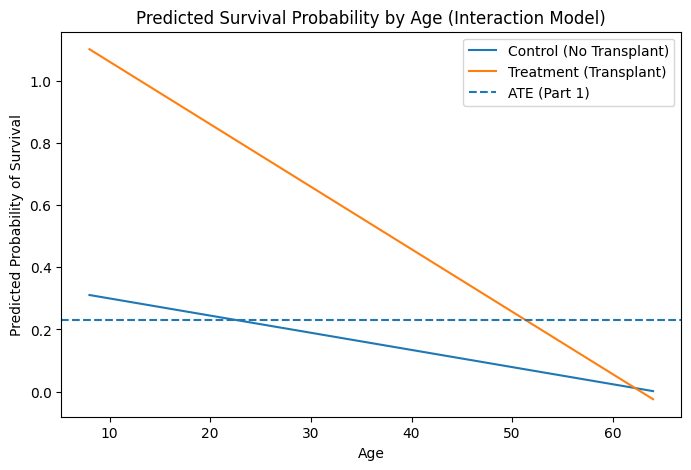

In [33]:
# Predict survival using interaction model

age_range = np.linspace(heart["age"].min(), heart["age"].max(), 100)

control_df = pd.DataFrame({
    "age": age_range,
    "transplant": "control"
})

treatment_df = pd.DataFrame({
    "age": age_range,
    "transplant": "treatment"
})

control_pred3 = model3.predict(control_df)
treatment_pred3 = model3.predict(treatment_df)

plt.figure(figsize=(8,5))

plt.plot(age_range, control_pred3, label="Control (No Transplant)")
plt.plot(age_range, treatment_pred3, label="Treatment (Transplant)")

plt.axhline(ATE, linestyle="--", label="ATE (Part 1)")

plt.xlabel("Age")
plt.ylabel("Predicted Probability of Survival")
plt.title("Predicted Survival Probability by Age (Interaction Model)")
plt.legend()

plt.show()

In [34]:
# Prepare data for sklearn models

X1 = pd.get_dummies(heart[["transplant"]], drop_first=True)
X2 = pd.get_dummies(heart[["transplant"]], drop_first=True)
X2["age"] = heart["age"]

X3 = pd.get_dummies(heart[["transplant"]], drop_first=True)
X3["age"] = heart["age"]
X3["interaction"] = X3["transplant_treatment"] * heart["age"]

y = heart["y"]

kf = KFold(n_splits=10, shuffle=True, random_state=1)

model = LinearRegression()

cv1 = cross_val_score(model, X1, y, cv=kf, scoring="neg_mean_squared_error")
cv2 = cross_val_score(model, X2, y, cv=kf, scoring="neg_mean_squared_error")
cv3 = cross_val_score(model, X3, y, cv=kf, scoring="neg_mean_squared_error")

print("Model 1 (transplant only) MSE:", -cv1.mean())
print("Model 2 (transplant + age) MSE:", -cv2.mean())
print("Model 3 (interaction) MSE:", -cv3.mean())

Model 1 (transplant only) MSE: 0.19497249586192156
Model 2 (transplant + age) MSE: 0.17926415954952163
Model 3 (interaction) MSE: 0.17880206762517337


**Q4 Answers**
1. The proportion of individuals who survived three years in the control group is 0.1176, while the proportion who survived in the treatment group is 0.3478. The Average Treatment Effect (ATE) is therefore 0.3478 − 0.1176 = 0.2302, meaning that receiving a heart transplant increases the probability of surviving three years by about 23 percentage points on average.

2. The regression of survival on transplant produced an intercept of 0.1176 and a transplant coefficient of 0.2302. The intercept represents the survival probability for the control group, which matches the control survival proportion calculated earlier. The transplant coefficient represents the difference in survival probability between the treatment and control groups and therefore matches the ATE computed in part 1.

3. When age is added to the regression, the transplant coefficient increases slightly to 0.2647, indicating that transplant recipients have about a 26.5 percentage point higher probability of survival after controlling for age. The age coefficient is −0.0136, meaning survival probability decreases as age increases. The intercept represents the predicted survival probability for the control group when age is zero. In the plot, the treatment and control prediction lines are parallel, indicating the model assumes a constant transplant effect across all ages. Because the ATE is a single average value, it may overestimate or underestimate the treatment effect for some ages.

4. When an interaction between transplant and age is included, the model allows the transplant effect to vary with age. The interaction coefficient is negative (−0.0146), which indicates that the survival benefit of a transplant decreases as age increases. This means younger patients tend to gain more benefit from a transplant, while the benefit becomes smaller for older patients. In the plot, the predicted survival lines are no longer parallel and instead converge as age increases.

5. The cross-validation results show that the transplant-only model has an MSE of 0.1950, the model with transplant and age has an MSE of 0.1793, and the interaction model has the lowest MSE at 0.1788. This indicates that including age improves predictive accuracy and that allowing transplant and age to interact slightly improves the model further.

6. If this model were used to prioritize transplant access, several concerns would arise. The model suggests younger patients benefit more from transplants, which could lead to age-based prioritization and fairness concerns. Additionally, the model only includes age and transplant status and does not account for many other medical factors that affect survival outcomes. Because of these limitations and ethical considerations, such models should be used cautiously and only as support for clinical decision-making rather than as the sole basis for allocating medical treatments.